In [5]:
import os
import torch
import matplotlib.pyplot as plt
os.chdir('..')
from RL4CRN.utils.lognormal import MultivariateLogNormal


# Example usage
d = 3
mu = torch.zeros(d)
L  = torch.tensor([[0.3, 0.0, 0.0],
                   [0.1, 0.2, 0.0],
                   [0.05,0.04,0.25]])           # Cholesky factor
Sigma = L @ L.T                                  # SPD covariance in log-space

mln = MultivariateLogNormal(mu, Sigma)
y   = mln.rsample((4,))   # [4, d]
lp  = mln.log_prob(y)     # [4]

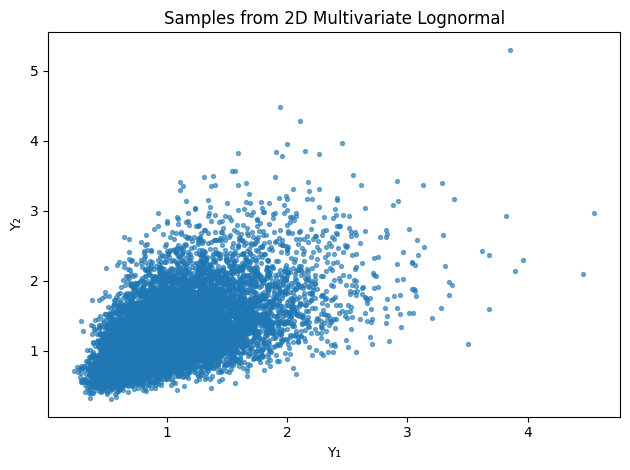

In [6]:
N = 10000  # number of samples

# 2D log-space parameters: X ~ N(μ, Σ)
mu = torch.tensor([0.0, 0.2])
L  = torch.tensor([[0.4, 0.0],
                    [0.2, 0.3]])  # Cholesky factor
Sigma = L @ L.T

dist = MultivariateLogNormal(mu, Sigma)
Y = dist.rsample((N,))  # shape [N, 2], positive samples

Y_np = Y.detach().cpu().numpy()
plt.figure()
plt.scatter(Y_np[:, 0], Y_np[:, 1], s=8, alpha=0.6)
plt.xlabel("Y₁")
plt.ylabel("Y₂")
plt.title("Samples from 2D Multivariate Lognormal")
plt.tight_layout()
plt.show()

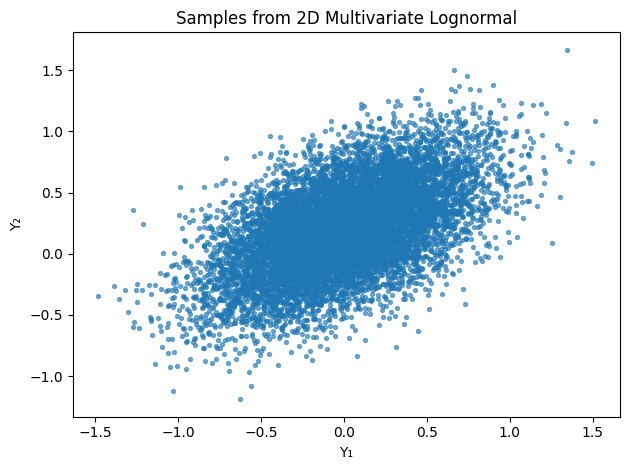

In [7]:
Y_log = torch.log(Y)  # log-space samples
Y_np_log = Y_log.detach().cpu().numpy()

plt.figure()
plt.scatter(Y_np_log[:, 0], Y_np_log[:, 1], s=8, alpha=0.6)
plt.xlabel("Y₁")
plt.ylabel("Y₂")
plt.title("Samples from 2D Multivariate Lognormal")
plt.tight_layout()
plt.show()